<a href="https://colab.research.google.com/github/Aakash-Arora-2006/Gesture-based-Human-Machine-Interaction-for-Factory-Automation/blob/main/Project1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Building an AI model to predict customer churning behaviour in telecom sector

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Load dataset
df = pd.read_csv("/Customer_churn_raw.csv")

# Target column
target_col = "Churn"
y = df[target_col]
X = df.drop(columns=[target_col])

# Convert categorical-like numeric columns if needed
for c in X.columns:
    if X[c].dtype == "object":
        try:
            X[c] = pd.to_numeric(X[c].str.replace(",",""), errors="coerce")
        except Exception:
            pass

# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Imputers
numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

# Preprocessor
numeric_transformer = Pipeline(steps=[("imputer", numeric_imputer), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", categorical_imputer), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    sparse_threshold=0
)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Pipeline with SMOTE + Random Forest
smote = SMOTE(random_state=42)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

best_pipe = ImbPipeline(steps=[
    ("pre", preprocessor),
    ("smote", smote),
    ("clf", rf_clf)
])

# Train
best_pipe.fit(X_train, y_train)

# Evaluate
y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9444444444444444
Precision: 0.82
Recall: 0.8282828282828283
F1: 0.8241206030150754
ROC AUC: 0.9817002415872472


Creating an ROC curve for the above trained model

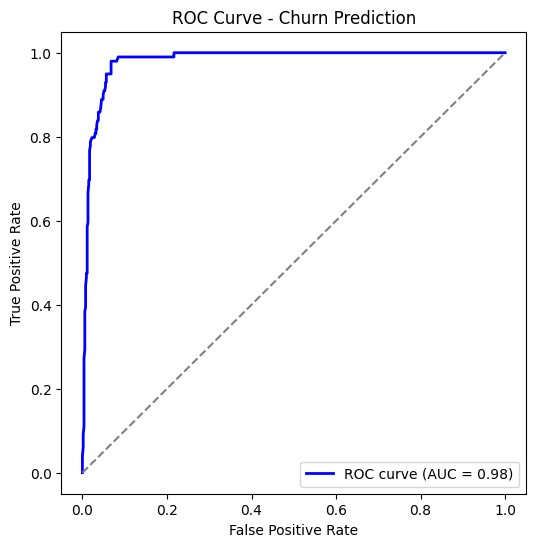

In [6]:
# Creating ROC curve for the model
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], color="gray", linestyle="--")  # diagonal reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction")
plt.legend(loc="lower right")
plt.show()


Plotting actual values vs predicted values

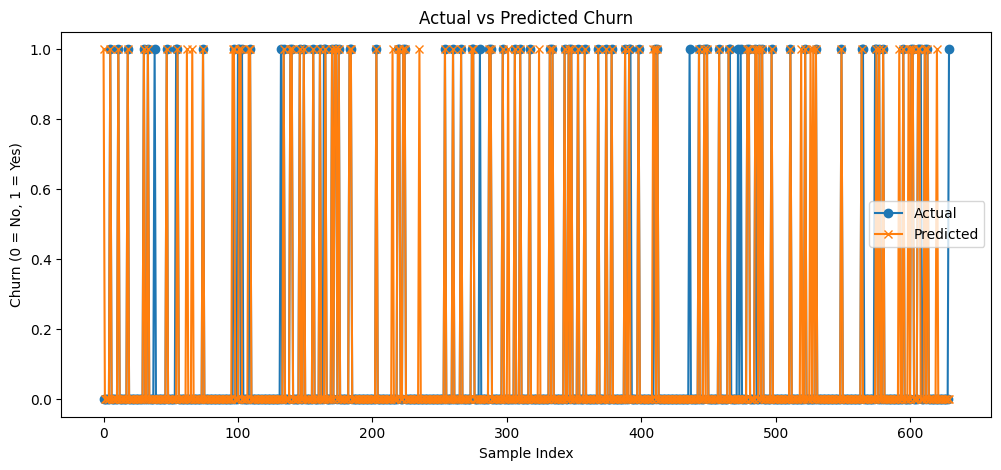

In [7]:
# Creating actual values vs predicted values curve
plt.figure(figsize=(12,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", marker="o")
plt.plot(range(len(y_pred)), y_pred, label="Predicted", marker="x")
plt.xlabel("Sample Index")
plt.ylabel("Churn (0 = No, 1 = Yes)")
plt.title("Actual vs Predicted Churn")
plt.legend()
plt.show()

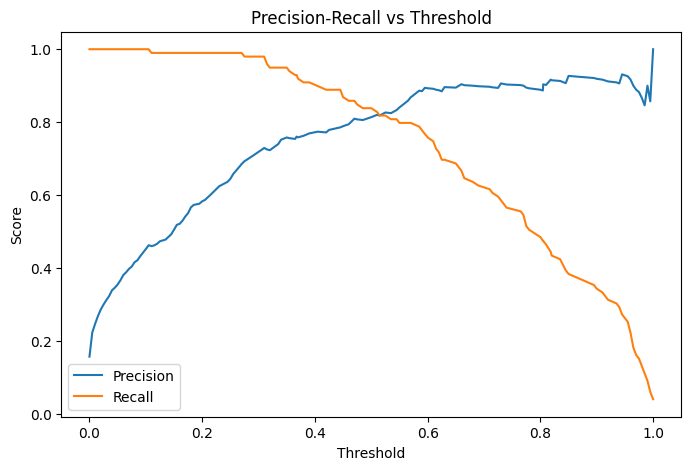

In [8]:
# Creating precision - recall threshold curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

From the above precision recall curve we can observe that one precision is high recall is less i.e. churners are left out.
When precision is low churner rate is very high might give wrong results. Optimal threshold is 0.4 - 0.5

Finally let's predict whether a customer will churn of not depending on the input parameters

In [9]:
# Making prediction for a new case
# Here we can put values for required parameters of a random customer and model will predict whether customer will churn or not
# depending on what it has learned from the input data
new_customer = pd.DataFrame([{
    "Call  Failure": 190,
    "Complains": 150,
    "Subscription  Length": 20,
    "Charge  Amount": 30,
    "Seconds of Use": 1000,
    "Frequency of use": 10,
    "Frequency of SMS": 10,
    "Distinct Called Numbers": 17,
    "Tariff Plan": 1,
    "Status": 1,
    "Age": 19,
    "Customer Value": 0,
    "FN": 4,
    "FP": 9,
    # add other required features if your dataset has more
}])

churn_prob = best_pipe.predict_proba(new_customer)[0][1]
churn_pred = best_pipe.predict(new_customer)[0]

print("\nNew Customer Prediction:")
print("Churn Probability:", churn_prob)
print("Churn Prediction (1=Yes, 0=No):", churn_pred)
print("Churn Probability:", churn_prob)


New Customer Prediction:
Churn Probability: 0.815
Churn Prediction (1=Yes, 0=No): 1
Churn Probability: 0.815


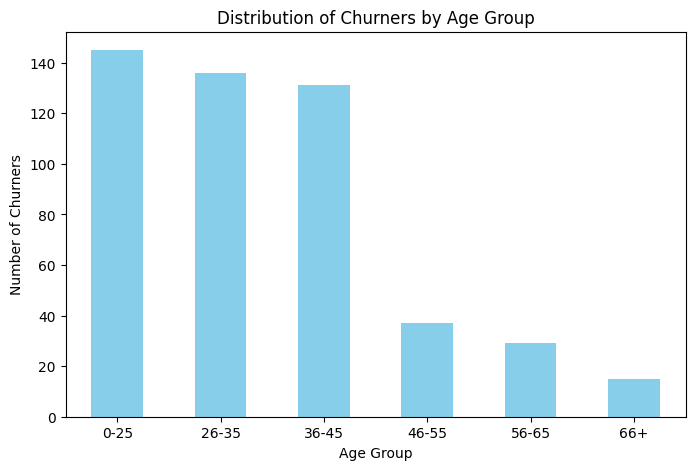

In [10]:

# Calssify Churners by Age Group

# Define age bins
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66+']

# Add age group column
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Filter churners
churners = df[df['Churn'] == 1]

# Count churners per age group
age_group_counts = churners['age_group'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
age_group_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Churners by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Churners')
plt.xticks(rotation=0)
plt.show()




/tmp/ipykernel_1044/288202725.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Charge  Amount'].fillna(df['Charge  Amount'].median(), inplace=True)


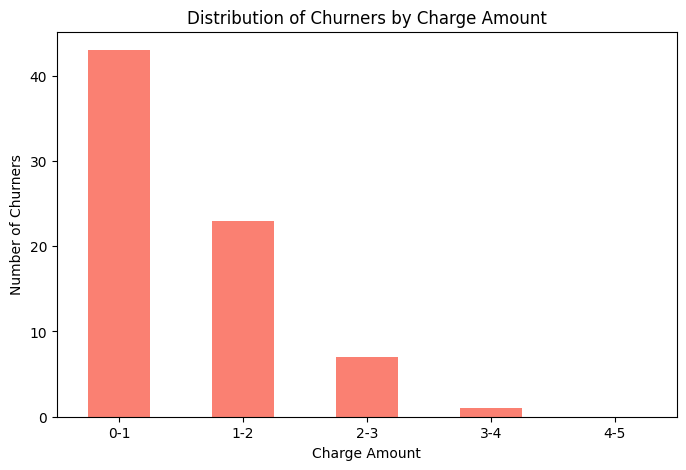

In [11]:
# classify churners on the basis of charge amount

# first we need to remove invalid values from charge amount data set
# Convert 'Charge  Amount' to numeric (coerce errors to NaN)
df['Charge  Amount'] = pd.to_numeric(df['Charge  Amount'], errors='coerce')

# Optional: fill missing values with median
df['Charge  Amount'].fillna(df['Charge  Amount'].median(), inplace=True)

# Now create charge group column
charge_bins = [0, 1, 2, 3, 4, 5]
charge_labels = ['0-1', '1-2', '2-3', '3-4', '4-5']
df['charge_group'] = pd.cut(df['Charge  Amount'], bins=charge_bins, labels=charge_labels)

# Filter churners
churners = df[df['Churn'] == 1]

# Count churners per charge group
charge_group_counts = churners['charge_group'].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
charge_group_counts.plot(kind='bar', color='salmon')
plt.title('Distribution of Churners by Charge Amount')
plt.xlabel('Charge Amount')
plt.ylabel('Number of Churners')
plt.xticks(rotation=0)
plt.show()
